# “AI Project Technical Evaluation Assistant”

In [117]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
import operator


In [118]:
load_dotenv()


True

In [119]:
model = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0.7
)


In [120]:
class EvaluationSchema(BaseModel):
    feedback:str=Field(description='Detailed analysis over input')
    rank: int = Field(description='Rank their idea out of 10',ge=0,le=10)


In [121]:
structured_model = model.with_structured_output(EvaluationSchema)


In [122]:
Topic = 'Build a real-time medical triage chatbot using LLMs and EHR data.'


In [123]:
prompt=f'Take ptoject idea as imput and you have to evaluate that idea with ranking out of 10 think of it as you are System Design Analylzer, decide yourself which domain it belong and analyze accordingly as a senior in that perticular field\n {Topic}'
structured_model.invoke(prompt).feedback


"The idea of building a real-time medical triage chatbot using LLMs and EHR data is a promising concept that aligns with the growing demand for telemedicine and AI-driven healthcare solutions. However, it requires careful consideration of several technical, ethical, and regulatory challenges, such as ensuring the accuracy and reliability of the chatbot's diagnoses, addressing issues related to data privacy and security, and obtaining necessary regulatory approvals. Furthermore, the development of such a chatbot would necessitate collaboration between experts from various fields, including natural language processing, healthcare informatics, and clinical medicine. Overall, the idea has a strong potential for impact, but it would be crucial to address the associated challenges and complexities to ensure its successful implementation and adoption."

In [124]:
class ProjectEvalState(TypedDict):
    idea:str
    fesibility_analyzer:str
    risk_analyzer:str
    industry_product_perspective:str
    ethics_compliance_review:str
    individual_scores:Annotated[list[int],operator.add]
    avg_score:float


In [125]:
def evaluate_fesibility(state:ProjectEvalState):
    prompt=f'Analyze the idea provided by the user take an eg. if user gives idea as Build a real-time medical triage chatbot using LLMs and EHR data.then here are fesibility analysis based on idea as,Evaluate: Required tech stack, Model complexity ,Infrastructure requirements ,Deployment challenges so take reference of this example and analyze any domain idea accordingly and score this analogy out of 10\n {state["idea"]}'
    output=structured_model.invoke(prompt)
    
    return {'fesibility_analyzer':output.feedback,'individual_scores':[output.rank]}


In [126]:
def evaluate_risk(state:ProjectEvalState):
    prompt=f'Analyze the idea provided by the user take an eg. if user gives idea as Build a real-time medical triage chatbot using LLMs and EHR data.then here are Data and ML Risk analysis based on idea as, Evaluate: Data availability ,Bias risks, Evaluation metrics ,Training complexity so take reference of this example and analyze any domain idea accordingly and score this analogy out of 10\n {state["idea"]}'
    output=structured_model.invoke(prompt)
    
    return {'risk_analyzer':output.feedback,'individual_scores':[output.rank]}


In [127]:
def industry_perspective_eval(state:ProjectEvalState):
    prompt=f'Analyze the idea provided by the user take an eg. if user gives idea as Build a real-time medical triage chatbot using LLMs and EHR data.then here are analysis over industry relevant product based on idea as,Evaluate:Real-world usefulness,Market deman,Scalability,Competitive landscape  so take reference of this example and analyze any domain idea accordingly and score this analogy out of 10\n {state["idea"]}'
    output=structured_model.invoke(prompt)
    
    return {'industry_product_perspective':output.feedback,'individual_scores':[output.rank]}


In [128]:
def ethics_compliance_review(state:ProjectEvalState):
    prompt=f'Analyze the idea provided by the user take an eg. if user gives idea as Build a real-time medical triage chatbot using LLMs and EHR data.then here are analysis over ethics and compliance review based on idea as,Evaluate:Privacy concerns,Regulatory risks,Safety implications,Responsible AI factors so take reference of this example and analyze any domain idea accordingly and score this analogy out of 10\n {state["idea"]}'
    output=structured_model.invoke(prompt)
    
    return {'ethics_compliance_review':output.feedback,'individual_scores':[output.rank]}


In [129]:
def final_evaluation(state:ProjectEvalState):
    prompt=f'''Based on the following analysis create a summarized feedback with final analysis following is the reference example : A junior AI engineer submits a short project proposal (for example: "Build a real-time medical triage chatbot using LLMs and EHR data."). 
 fesibility analyzer - {state["fesibility_analyzer"]} 
 risk analyzer - {state["risk_analyzer"]} 
 industry product perspective - {state["industry_product_perspective"]}
 ethics and compliance review - {state["ethics_compliance_review"]} take above example as referece for any other domain provide similar kind of final evaluation'''
    
    overall_feedback = model.invoke(prompt).content

    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}


In [130]:
#   idea:str
#     tech_fesiblity_analyzer:str
#     tech_risk_analyzer:str
#     industry_product_perspective:str
#     ethics_compliance_review:str
#     individual_score:Annotated[list[int],operator.add]
#     # rank_idea:float


In [131]:

graph = StateGraph(ProjectEvalState)

graph.add_node('evaluate_fesibility', evaluate_fesibility)
graph.add_node('evaluate_risk', evaluate_risk)
graph.add_node('industry_perspective_eval', industry_perspective_eval)
graph.add_node('ethics_compliance_review', ethics_compliance_review)
graph.add_node('final_evaluation',final_evaluation)

# edges
graph.add_edge(START, 'evaluate_fesibility')
graph.add_edge(START, 'evaluate_risk')
graph.add_edge(START, 'industry_perspective_eval')
graph.add_edge(START, 'ethics_compliance_review')


graph.add_edge('evaluate_fesibility', 'final_evaluation')
graph.add_edge('evaluate_risk', 'final_evaluation')
graph.add_edge('industry_perspective_eval', 'final_evaluation')
graph.add_edge('ethics_compliance_review','final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()


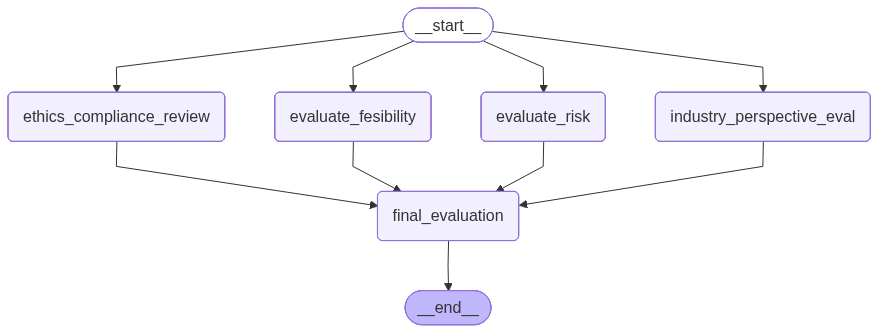

In [132]:
workflow


In [133]:
idea='AI-Powered Real-Time Fraud Detection & Credit Risk Scoring System for Digital Lending Platforms.'


In [134]:
initial_state={'idea':idea}


In [135]:
workflow.invoke(initial_state)


{'idea': 'AI-Powered Real-Time Fraud Detection & Credit Risk Scoring System for Digital Lending Platforms.',
 'fesibility_analyzer': 'The idea of an AI-Powered Real-Time Fraud Detection & Credit Risk Scoring System for Digital Lending Platforms is feasible but requires a robust tech stack, including machine learning algorithms, data preprocessing techniques, and integration with credit scoring models. ',
 'risk_analyzer': 'AI-Powered Real-Time Fraud Detection & Credit Risk Scoring System for Digital Lending Platforms analysis: Data availability is high due to existing lending datasets, Bias risks are moderate due to potential for unfair credit scoring, Evaluation metrics include Accuracy, F1-score, and AUC-ROC, Training complexity is medium due to the need for large and diverse datasets, and domain-specific expertise. Overall score: 8/10',
 'industry_product_perspective': 'The idea of an AI-Powered Real-Time Fraud Detection & Credit Risk Scoring System for Digital Lending Platforms has